# Phase 3: Machine Learning - Churn Prediction & Customer Segmentation

**Goal:** Build ML models to predict customer churn and segment customers using clustering

**Tools:** Python, Scikit-learn, Pandas, NumPy, Matplotlib, Seaborn

**Models:** Logistic Regression, Decision Tree, Random Forest, K-Means Clustering

---

## Table of Contents
- [Step 1: Problem Definition & Data Preparation](#Step-1)
- [Step 2: Logistic Regression (Baseline)](#Step-2)
- [Step 3: Decision Tree & K-Means Clustering](#Step-3)
- [Step 4: Random Forest & Model Comparison](#Step-4)
- [Step 5: Business Recommendations & Final Report](#Step-5)

---

<a id='Step-1'></a>
# Step 1 : Problem Definition & Data Preparation

## Objectives:
- Define what "churn" means for this business
- Create target variable (churned vs. active)
- Prepare features for ML models
- Split data into train/test sets

## What is Churn?
Churn = customers who have stopped purchasing from the business

**Our Definition:** Customers who haven't made a purchase in the last 60+ days are considered churned.

In [2]:
!python -m pip install scikit-learn

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    silhouette_score
)

# Visualisation settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" All libraries imported!")

 All libraries imported!


## 1.1 Load Feature Data from Phase 2

In [4]:
# Load the customer features created in Phase 2
customer_features = pd.read_csv('customer_features_reduced.csv')

print(f" Data Loaded:")
print(f"   • Total customers: {len(customer_features):,}")
print(f"   • Total features: {customer_features.shape[1]}")
print(f"\n Feature columns:")
for col in customer_features.columns:
    print(f"   • {col}")

 Data Loaded:
   • Total customers: 4,315
   • Total features: 8

 Feature columns:
   • customer_id
   • recency
   • frequency
   • monetary
   • avg_order_value
   • unique_products_purchased
   • std_basket_value
   • preferred_day_count


In [5]:
# Preview the data
print("\n Sample Data:")
display(customer_features.head(10))

print("\n Data Info:")
customer_features.info()


 Sample Data:


,customer_id,recency,frequency,monetary,avg_order_value,unique_products_purchased,std_basket_value,preferred_day_count
0,12347,2,7,4310.00,615.714286,103,341.070789,53
1,12348,75,4,1797.24,449.310000,22,301.159918,17
2,12349,19,1,1757.55,1757.550000,73,0.000000,73
3,12350,310,1,334.40,334.400000,17,0.000000,17
4,12352,36,11,1545.41,140.491818,59,362.141759,44
5,12353,204,1,89.00,89.000000,4,0.000000,4
6,12354,232,1,1079.40,1079.400000,58,0.000000,58
7,12355,214,1,459.40,459.400000,13,0.000000,13
8,12356,23,3,2811.43,937.143333,53,1174.894250,36
9,12357,33,1,6207.67,6207.670000,131,0.000000,131



 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 4315 entries, 0 to 4314
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4315 non-null   int64  
 1   recency                    4315 non-null   int64  
 2   frequency                  4315 non-null   int64  
 3   monetary                   4315 non-null   float64
 4   avg_order_value            4315 non-null   float64
 5   unique_products_purchased  4315 non-null   int64  
 6   std_basket_value           4315 non-null   float64
 7   preferred_day_count        4315 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 269.8 KB


## 1.2 Define Churn Target Variable

DEFINING CHURN TARGET VARIABLE

 Churn Definition:
   Customers who haven't purchased in last 60 days = CHURNED

 Class Distribution:
   • Active (0): 2,428 customers (56.3%)
   • Churned (1): 1,887 customers (43.7%)


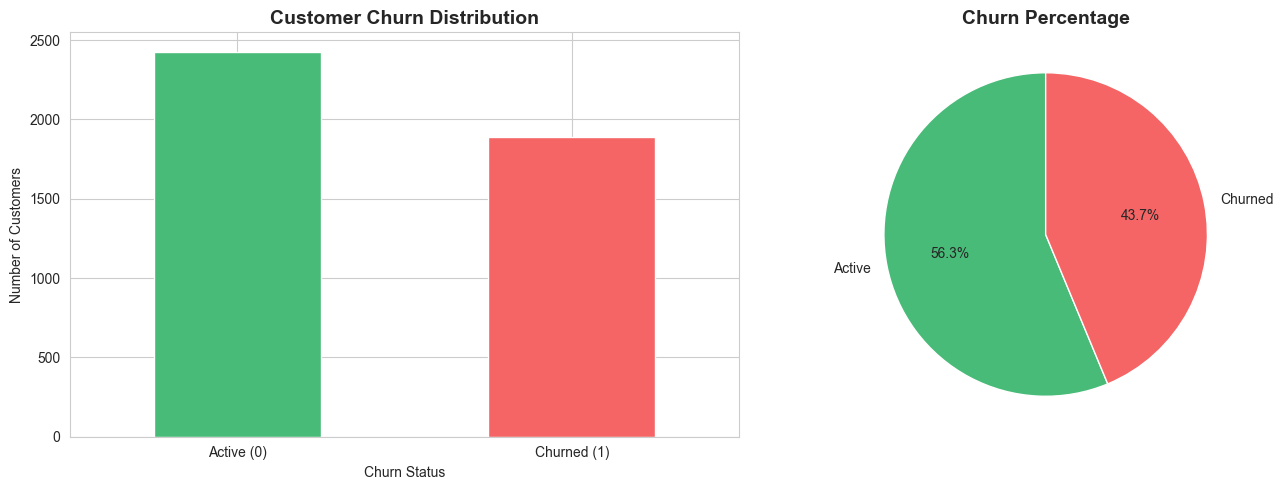


 Churn target variable created!


In [6]:
print("="*60)
print("DEFINING CHURN TARGET VARIABLE")
print("="*60)

# Define churn threshold (days since last purchase)
CHURN_THRESHOLD = 60  # days

print(f"\n Churn Definition:")
print(f"   Customers who haven't purchased in last {CHURN_THRESHOLD} days = CHURNED")

# Create binary target variable
# If days_since_last_purchase > threshold → churned (1), else active (0)
customer_features['churned'] = (customer_features['recency'] > CHURN_THRESHOLD).astype(int)

# Check class distribution
churn_counts = customer_features['churned'].value_counts()
churn_pct = customer_features['churned'].value_counts(normalize=True) * 100

print(f"\n Class Distribution:")
print(f"   • Active (0): {churn_counts[0]:,} customers ({churn_pct[0]:.1f}%)")
print(f"   • Churned (1): {churn_counts[1]:,} customers ({churn_pct[1]:.1f}%)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
churn_counts.plot(kind='bar', ax=axes[0], color=['#48bb78', '#f56565'])
axes[0].set_title('Customer Churn Distribution', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Active (0)', 'Churned (1)'], rotation=0)

# Pie chart
axes[1].pie(churn_counts, labels=['Active', 'Churned'], autopct='%1.1f%%', 
            colors=['#48bb78', '#f56565'], startangle=90)
axes[1].set_title('Churn Percentage', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Churn target variable created!")

## 1.3 Prepare Features for ML

In [7]:
print("="*60)
print("PREPARING FEATURES FOR MACHINE LEARNING")
print("="*60)

# Drop customer_id (not a feature) and any columns we don't want as features
features_to_drop = ['customer_id', 'churned']  # Drop ID and target

# Check for categorical columns that need encoding
categorical_cols = customer_features.select_dtypes(include=['object']).columns.tolist()

print(f"\n Categorical columns found: {categorical_cols}")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    if col not in features_to_drop:
        le = LabelEncoder()
        customer_features[f'{col}_encoded'] = le.fit_transform(customer_features[col].astype(str))
        label_encoders[col] = le
        print(f"   ✓ Encoded: {col} → {col}_encoded")
        # Drop original categorical column
        features_to_drop.append(col)

# Separate features (X) and target (y)
X = customer_features.drop(columns=features_to_drop)
y = customer_features['churned']

print(f"\n Features prepared:")
print(f"   • X shape: {X.shape}")
print(f"   • y shape: {y.shape}")
print(f"\n Feature columns for ML ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

PREPARING FEATURES FOR MACHINE LEARNING

 Categorical columns found: []

 Features prepared:
   • X shape: (4315, 7)
   • y shape: (4315,)

 Feature columns for ML (7):
   1. recency
   2. frequency
   3. monetary
   4. avg_order_value
   5. unique_products_purchased
   6. std_basket_value
   7. preferred_day_count


## 1.4 Train-Test Split

In [8]:
print("="*60)
print("SPLITTING DATA: TRAIN (80%) vs TEST (20%)")
print("="*60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class balance in both sets
)

print(f"\n Data Split Summary:")
print(f"   • Training set: {len(X_train):,} customers ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Test set: {len(X_test):,} customers ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n Class distribution in training set:")
print(f"   • Active: {(y_train == 0).sum():,} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"   • Churned: {(y_train == 1).sum():,} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print(f"\n Class distribution in test set:")
print(f"   • Active: {(y_test == 0).sum():,} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"   • Churned: {(y_test == 1).sum():,} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

print("\n Train-test split complete!")

SPLITTING DATA: TRAIN (80%) vs TEST (20%)

 Data Split Summary:
   • Training set: 3,452 customers (80.0%)
   • Test set: 863 customers (20.0%)

 Class distribution in training set:
   • Active: 1,942 (56.3%)
   • Churned: 1,510 (43.7%)

 Class distribution in test set:
   • Active: 486 (56.3%)
   • Churned: 377 (43.7%)

 Train-test split complete!


## Step 1 Summary

In [9]:
print("\n" + "="*60)
print(" Step 1 COMPLETE: PROBLEM DEFINITION & DATA PREPARATION")
print("="*60)
print("""
What We Accomplished:
   ✓ Defined churn (60+ days since last purchase)
   ✓ Created binary target variable (churned = 1, active = 0)
   ✓ Encoded categorical variables
   ✓ Split data into training (80%) and test (20%) sets
   ✓ Verified class balance

Next Step 2: Logistic Regression (Baseline Model)
""")


 Step 1 COMPLETE: PROBLEM DEFINITION & DATA PREPARATION

What We Accomplished:
   ✓ Defined churn (60+ days since last purchase)
   ✓ Created binary target variable (churned = 1, active = 0)
   ✓ Encoded categorical variables
   ✓ Split data into training (80%) and test (20%) sets
   ✓ Verified class balance

Next Step 2: Logistic Regression (Baseline Model)



---
<a id='Step-2'></a>
# Step 2: Logistic Regression (Baseline Model)

## Objectives:
- Scale features for Logistic Regression
- Train baseline model
- Evaluate performance metrics
- Analyse feature importance

## Why Logistic Regression?
- Simple, interpretable baseline
- Fast to train
- Provides probability scores
- Feature coefficients show importance

## 2.1 Feature Scaling

In [10]:
print("="*60)
print("FEATURE SCALING (STANDARDISATION)")
print("="*60)

# Logistic Regression requires scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Features scaled using StandardScaler")
print(f"   • Mean ≈ 0, Standard Deviation ≈ 1")
print(f"\n Sample scaled values (first 5 features, first customer):")
print(X_train_scaled[0, :5])

FEATURE SCALING (STANDARDISATION)

 Features scaled using StandardScaler
   • Mean ≈ 0, Standard Deviation ≈ 1

 Sample scaled values (first 5 features, first customer):
[-0.51804616 -0.34992055 -0.20123404 -0.64967872 -0.61816642]


## 2.2 Train Logistic Regression Model

In [11]:
print("="*60)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*60)

# Train model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("\n Logistic Regression model trained!")

# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probability of churn

print(f"\n Predictions made on {len(y_test):,} test customers")

TRAINING LOGISTIC REGRESSION MODEL

 Logistic Regression model trained!

 Predictions made on 863 test customers


## 2.3 Evaluate Model Performance

In [12]:
print("="*60)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*60)

# Calculate metrics
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_pred_proba_log)

print(f"\n Model Performance:")
print(f"   • Accuracy:  {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")
print(f"   • Precision: {precision_log:.4f} ({precision_log*100:.2f}%)")
print(f"   • Recall:    {recall_log:.4f} ({recall_log*100:.2f}%)")
print(f"   • F1-Score:  {f1_log:.4f}")
print(f"   • ROC-AUC:   {roc_auc_log:.4f}")

print(f"\n What do these metrics mean?")
print(f"   • Accuracy:  Overall correctness")
print(f"   • Precision: Of predicted churned, how many actually churned?")
print(f"   • Recall:    Of actual churned, how many did we catch?")
print(f"   • F1-Score:  Balance between precision and recall")
print(f"   • ROC-AUC:   Model's ability to distinguish classes (0.5=random, 1.0=perfect)")

LOGISTIC REGRESSION - PERFORMANCE METRICS

 Model Performance:
   • Accuracy:  0.9907 (99.07%)
   • Precision: 1.0000 (100.00%)
   • Recall:    0.9788 (97.88%)
   • F1-Score:  0.9893
   • ROC-AUC:   0.9999

 What do these metrics mean?
   • Accuracy:  Overall correctness
   • Precision: Of predicted churned, how many actually churned?
   • Recall:    Of actual churned, how many did we catch?
   • F1-Score:  Balance between precision and recall
   • ROC-AUC:   Model's ability to distinguish classes (0.5=random, 1.0=perfect)


## 2.4 Confusion Matrix

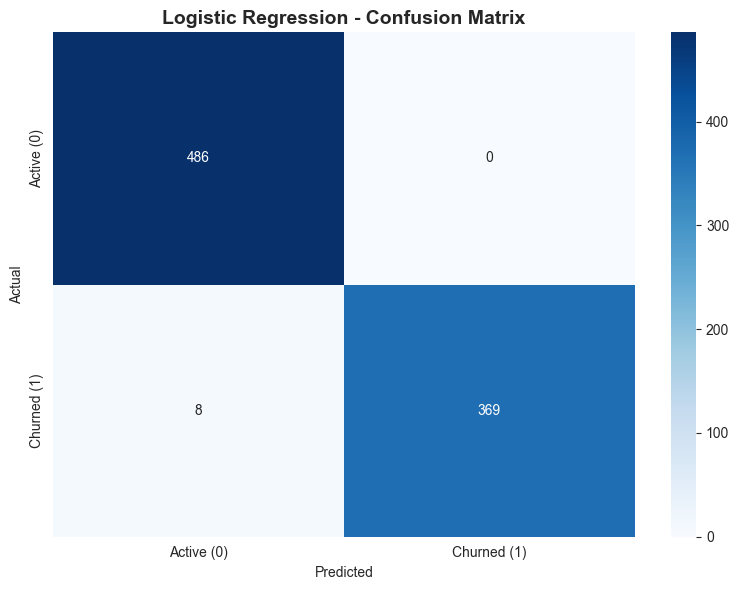


 Confusion Matrix Breakdown:
   • True Negatives (Correct Active):  486
   • False Positives (Wrong Churn):    0
   • False Negatives (Missed Churn):   8
   • True Positives (Correct Churn):   369


In [13]:
# Create confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Active (0)', 'Churned (1)'],
            yticklabels=['Active (0)', 'Churned (1)'])
plt.title('Logistic Regression - Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Confusion Matrix Breakdown:")
print(f"   • True Negatives (Correct Active):  {cm_log[0, 0]:,}")
print(f"   • False Positives (Wrong Churn):    {cm_log[0, 1]:,}")
print(f"   • False Negatives (Missed Churn):   {cm_log[1, 0]:,}")
print(f"   • True Positives (Correct Churn):   {cm_log[1, 1]:,}")

## 2.5 ROC Curve

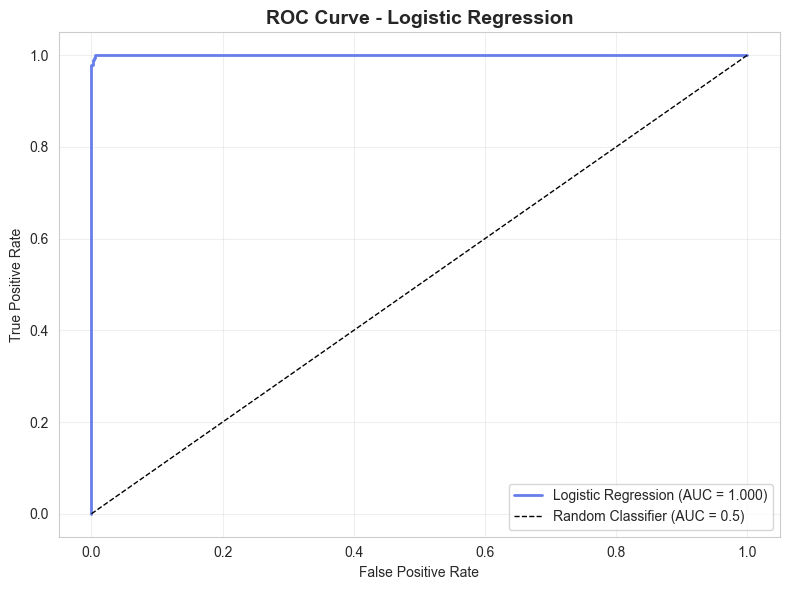

 ROC curve plotted


In [14]:
# Calculate ROC curve
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_proba_log)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='#667eea', linewidth=2, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

print(" ROC curve plotted")

## 2.6 Feature Importance (Coefficients)

FEATURE IMPORTANCE ANALYSIS

 Top 10 Most Important Features:
                  feature  coefficient  abs_coefficient
                  recency    13.754348        13.754348
         std_basket_value    -0.242342         0.242342
                 monetary    -0.224955         0.224955
unique_products_purchased    -0.196607         0.196607
          avg_order_value     0.131574         0.131574
                frequency    -0.100824         0.100824
      preferred_day_count    -0.091363         0.091363


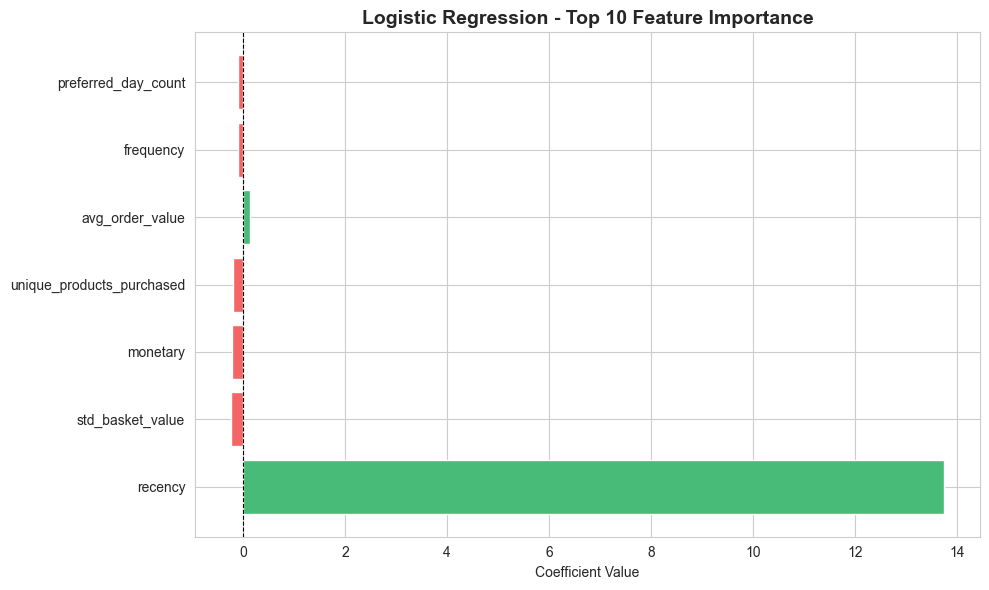


 Interpretation:
   • Positive coefficient → increases churn probability
   • Negative coefficient → decreases churn probability
   • Larger absolute value → stronger influence


In [15]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature coefficients
feature_importance_log = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'abs_coefficient': np.abs(log_reg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\n Top 10 Most Important Features:")
print(feature_importance_log.head(10).to_string(index=False))

# Visualise top 10
top_10_features = feature_importance_log.head(10)

plt.figure(figsize=(10, 6))
colors = ['#f56565' if x < 0 else '#48bb78' for x in top_10_features['coefficient']]
plt.barh(range(len(top_10_features)), top_10_features['coefficient'], color=colors)
plt.yticks(range(len(top_10_features)), top_10_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression - Top 10 Feature Importance', fontweight='bold', fontsize=14)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   • Positive coefficient → increases churn probability")
print("   • Negative coefficient → decreases churn probability")
print("   • Larger absolute value → stronger influence")

## Error Identified:
The results are too good to be true. The reason might be because we used Recency to define Churn. Then used Recency as a predictor.

So the model is not “predicting” churn. It is "rediscovering" the initial rule.

✅ 1️⃣ PREPARING FEATURES FOR ML (Fixed — No Leakage)

In [16]:
print("="*60)
print("PREPARING FEATURES FOR MACHINE LEARNING")
print("="*60)

# Columns we NEVER use as features
features_to_drop = ['customer_id', 'churned', 'recency']  # 🚨 removed recency (Data Leakage)

# Detect categorical columns
categorical_cols = customer_features.select_dtypes(include=['object']).columns.tolist()

print(f"\n Categorical columns found: {categorical_cols}")

# Encode categorical variables (except dropped ones)
label_encoders = {}

for col in categorical_cols:
    if col not in features_to_drop:
        le = LabelEncoder()
        customer_features[f'{col}_encoded'] = le.fit_transform(customer_features[col].astype(str))
        label_encoders[col] = le
        print(f"   ✓ Encoded: {col} → {col}_encoded")
        features_to_drop.append(col)  # drop original after encoding

# Separate features and target
X = customer_features.drop(columns=features_to_drop)
y = customer_features['churned']

print(f"\n Features prepared:")
print(f"   • X shape: {X.shape}")
print(f"   • y shape: {y.shape}")

print(f"\n Feature columns for ML ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i}. {col}")

PREPARING FEATURES FOR MACHINE LEARNING

 Categorical columns found: []

 Features prepared:
   • X shape: (4315, 6)
   • y shape: (4315,)

 Feature columns for ML (6):
   1. frequency
   2. monetary
   3. avg_order_value
   4. unique_products_purchased
   5. std_basket_value
   6. preferred_day_count


✅ 2️⃣ TRAIN–TEST SPLIT (Keep, Small Safety Addition)

In [17]:
print("="*60)
print("SPLITTING DATA: TRAIN (80%) vs TEST (20%)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"\n Data Split Summary:")
print(f"   • Training set: {len(X_train):,} customers ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Test set: {len(X_test):,} customers ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n Class distribution in training set:")
print(f"   • Active: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"   • Churned: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")

print(f"\n Class distribution in test set:")
print(f"   • Active: {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"   • Churned: {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)")

print("\n Train-test split complete!")

SPLITTING DATA: TRAIN (80%) vs TEST (20%)

 Data Split Summary:
   • Training set: 3,452 customers (80.0%)
   • Test set: 863 customers (20.0%)

 Class distribution in training set:
   • Active: 1,942 (56.3%)
   • Churned: 1,510 (43.7%)

 Class distribution in test set:
   • Active: 486 (56.3%)
   • Churned: 377 (43.7%)

 Train-test split complete!


✅ 3️⃣ FEATURE SCALING (Correct)

In [18]:
print("="*60)
print("FEATURE SCALING (STANDARDISATION)")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Features scaled using StandardScaler")
print(f"   • Mean ≈ 0, Standard Deviation ≈ 1")

print(f"\n Sample scaled values (first 5 features, first customer):")
print(X_train_scaled[0, :5])

FEATURE SCALING (STANDARDISATION)

 Features scaled using StandardScaler
   • Mean ≈ 0, Standard Deviation ≈ 1

 Sample scaled values (first 5 features, first customer):
[-0.34992055 -0.20123404 -0.64967872 -0.61816642 -0.07952025]


✅ 4️⃣ TRAIN LOGISTIC REGRESSION (On Improved Data)

In [19]:
print("="*60)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*60)

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  # helps with class imbalance
)

log_reg.fit(X_train_scaled, y_train)

print("\n✅ Logistic Regression model trained!")

# Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 Predictions made on {len(y_test):,} test customers")

TRAINING LOGISTIC REGRESSION MODEL

✅ Logistic Regression model trained!

📊 Predictions made on 863 test customers


In [20]:
print("="*60)
print("THRESHOLD OPTIMISATION")
print("="*60)

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = np.arange(0.30, 0.81, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_log >= t).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred_custom)
    precision = precision_score(y_test, y_pred_custom, zero_division=0)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    
    results.append((t, accuracy, precision, recall, f1))

# Display results
print(f"{'Threshold':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
for r in results:
    print(f"{r[0]:<10.2f} {r[1]:<10.3f} {r[2]:<10.3f} {r[3]:<10.3f} {r[4]:<10.3f}")

THRESHOLD OPTIMISATION
Threshold  Accuracy   Precision  Recall     F1-Score  
0.30       0.620      0.538      0.931      0.682     
0.35       0.638      0.552      0.915      0.689     
0.40       0.649      0.562      0.891      0.689     
0.45       0.669      0.580      0.875      0.698     
0.50       0.684      0.599      0.833      0.697     
0.55       0.705      0.631      0.780      0.698     
0.60       0.699      0.640      0.708      0.673     
0.65       0.684      0.668      0.549      0.603     
0.70       0.654      0.693      0.371      0.484     
0.75       0.561      0.438      0.019      0.036     
0.80       0.562      0.400      0.005      0.010     


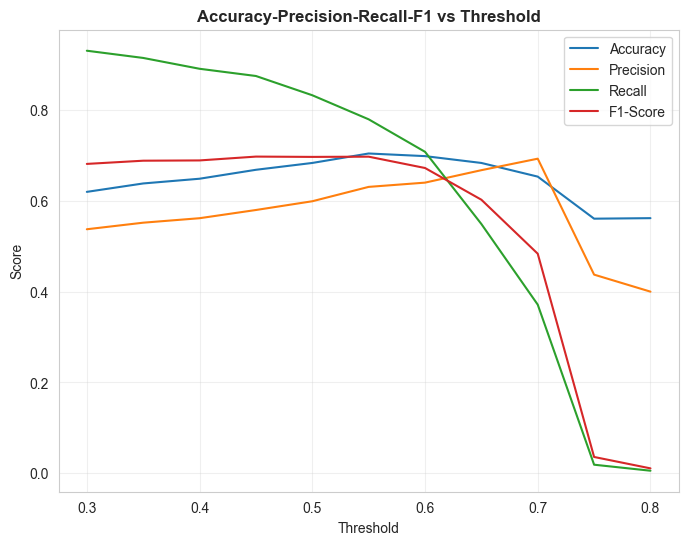

In [21]:
import matplotlib.pyplot as plt

accuracies = [r[1] for r in results]
precisions = [r[2] for r in results]
recalls = [r[3] for r in results]
f1_scores = [r[4] for r in results]

plt.figure(figsize=(8,6))
plt.plot(thresholds, accuracies, label="Accuracy")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1-Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Accuracy-Precision-Recall-F1 vs Threshold", fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

✅ 5️⃣ PERFORMANCE METRICS (Add Zero-Division Safety)

In [22]:
print("="*60)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*60)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log, zero_division=0)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_pred_proba_log)

print(f"\n Model Performance:")
print(f"   • Accuracy:  {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")
print(f"   • Precision: {precision_log:.4f} ({precision_log*100:.2f}%)")
print(f"   • Recall:    {recall_log:.4f} ({recall_log*100:.2f}%)")
print(f"   • F1-Score:  {f1_log:.4f}")
print(f"   • ROC-AUC:   {roc_auc_log:.4f}")
print(" Threshold kept at original 0.5, for optimum possible performance of the model")

LOGISTIC REGRESSION - PERFORMANCE METRICS

 Model Performance:
   • Accuracy:  0.6837 (68.37%)
   • Precision: 0.5992 (59.92%)
   • Recall:    0.8329 (83.29%)
   • F1-Score:  0.6970
   • ROC-AUC:   0.7598
 Threshold kept at original 0.5, for optimum possible performance of the model


✅ 6️⃣ CONFUSION MATRIX

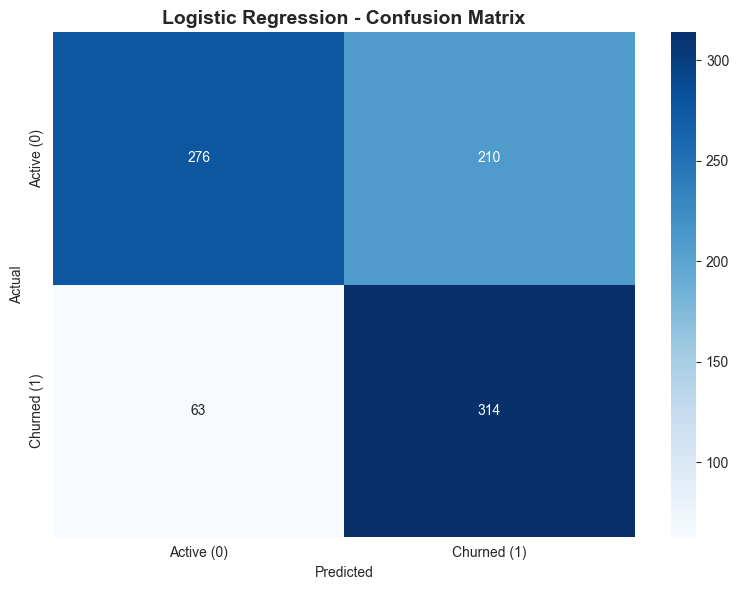


 Confusion Matrix Breakdown:
   • True Negatives (Correct Active):  276
   • False Positives (Wrong Churn):    210
   • False Negatives (Missed Churn):   63
   • True Positives (Correct Churn):   314


In [23]:
# Create confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Visualise
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Active (0)', 'Churned (1)'],
            yticklabels=['Active (0)', 'Churned (1)'])
plt.title('Logistic Regression - Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Confusion Matrix Breakdown:")
print(f"   • True Negatives (Correct Active):  {cm_log[0, 0]:,}")
print(f"   • False Positives (Wrong Churn):    {cm_log[0, 1]:,}")
print(f"   • False Negatives (Missed Churn):   {cm_log[1, 0]:,}")
print(f"   • True Positives (Correct Churn):   {cm_log[1, 1]:,}")

Correctness of positive predictions
    Precision = TP / (TP+FP)

Finding all real positives
    Recall = TP / (TP+FN)

✅ 7️⃣ ROC CURVE

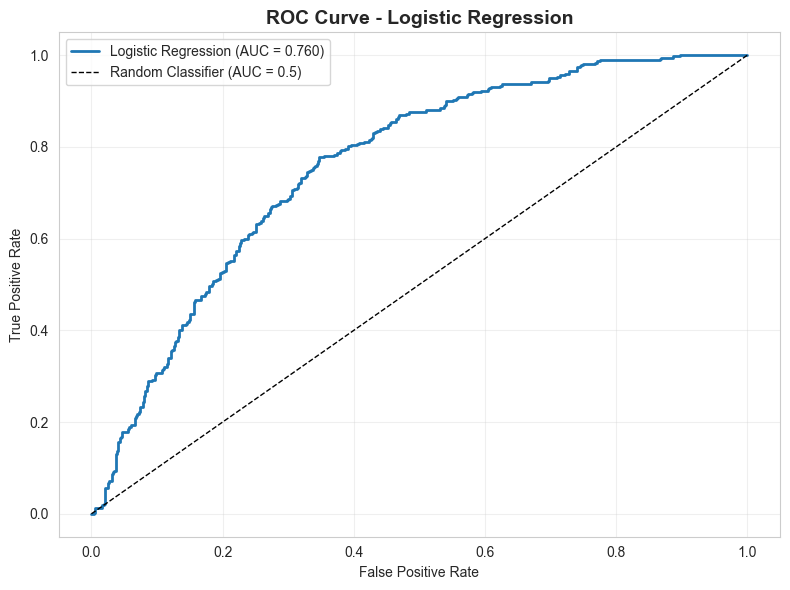

 ROC curve plotted


In [24]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_proba_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, linewidth=2, label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

print(" ROC curve plotted")

✅ 8️⃣ FEATURE IMPORTANCE (Improved)

FEATURE IMPORTANCE ANALYSIS

 Top 10 Most Important Features:
                  feature  coefficient  abs_coefficient
                frequency    -1.655560         1.655560
unique_products_purchased    -1.318331         1.318331
                 monetary    -0.657446         0.657446
      preferred_day_count     0.568067         0.568067
          avg_order_value     0.211416         0.211416
         std_basket_value    -0.041964         0.041964


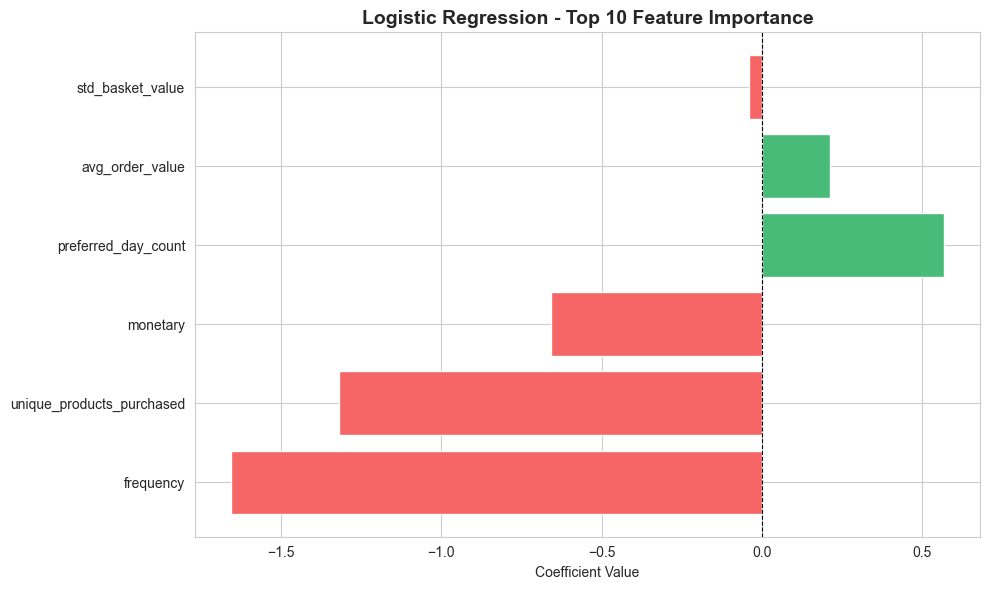


 Interpretation:
   • Positive coefficient → increases churn probability
   • Negative coefficient → decreases churn probability
   • Larger absolute value → stronger influence


In [25]:
print("="*60) 
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

import pandas as pd
import numpy as np

feature_importance_log = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'abs_coefficient': np.abs(log_reg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\n Top 10 Most Important Features:")
print(feature_importance_log.head(10).to_string(index=False))

# Visualize top 10
top_10_features = feature_importance_log.head(10)

plt.figure(figsize=(10, 6))
colors = ['#f56565' if x < 0 else '#48bb78' for x in top_10_features['coefficient']]
plt.barh(range(len(top_10_features)), top_10_features['coefficient'], color=colors)
plt.yticks(range(len(top_10_features)), top_10_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression - Top 10 Feature Importance', fontweight='bold', fontsize=14)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_logistic.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   • Positive coefficient → increases churn probability")
print("   • Negative coefficient → decreases churn probability")
print("   • Larger absolute value → stronger influence")

The logistic regression coefficients show that purchase frequency is the strongest predictor of churn, with a large negative coefficient, indicating that frequent buyers are significantly less likely to churn. In contrast, average order value has a small positive coefficient, suggesting that customers who place larger but less frequent orders may have a slightly higher likelihood of churning.


In [26]:
model_results = {}

# Update logistic regression results
model_results['Logistic Regression'] = {
    'Accuracy': accuracy_log,
    'Precision': precision_log,
    'Recall': recall_log,
    'F1-Score': f1_log,
    'ROC-AUC': roc_auc_log
}

---
<a id='Step-3'></a>
# Step 3: Decision Tree & K-Means Clustering

## Objectives:
- Train Decision Tree classifier (supervised)
- Perform K-Means Clustering (unsupervised) on RFM scores
- Segment customers into meaningful groups
- Visualise customer segments

## Part A: Decision Tree for Churn Prediction
## Part B: K-Means for Customer Segmentation

## 3A.1 Train Decision Tree Model

In [27]:
print("="*60)
print("PART A: DECISION TREE FOR CHURN PREDICTION")
print("="*60)

# Decision trees don't require scaling
# Start with basic tree
dt_model = DecisionTreeClassifier(
    max_depth=5,  # Limit depth to avoid overfitting
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("\n Decision Tree trained!")
print(f"   • Max depth: {dt_model.get_depth()}")
print(f"   • Number of leaves: {dt_model.get_n_leaves()}")

PART A: DECISION TREE FOR CHURN PREDICTION

 Decision Tree trained!
   • Max depth: 5
   • Number of leaves: 29


## 3A.2 Evaluate Decision Tree

In [28]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print("="*60)
print("DECISION TREE - PERFORMANCE METRICS")
print("="*60)
print(f"\n Model Performance:")
print(f"   • Accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"   • Precision: {precision_dt:.4f} ({precision_dt*100:.2f}%)")
print(f"   • Recall:    {recall_dt:.4f} ({recall_dt*100:.2f}%)")
print(f"   • F1-Score:  {f1_dt:.4f}")
print(f"   • ROC-AUC:   {roc_auc_dt:.4f}")

# Store results
model_results['Decision Tree'] = {
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt,
    'ROC-AUC': roc_auc_dt
}

DECISION TREE - PERFORMANCE METRICS

 Model Performance:
   • Accuracy:  0.6663 (66.63%)
   • Precision: 0.6320 (63.20%)
   • Recall:    0.5650 (56.50%)
   • F1-Score:  0.5966
   • ROC-AUC:   0.7435


## 3A.3 Visualise Decision Tree

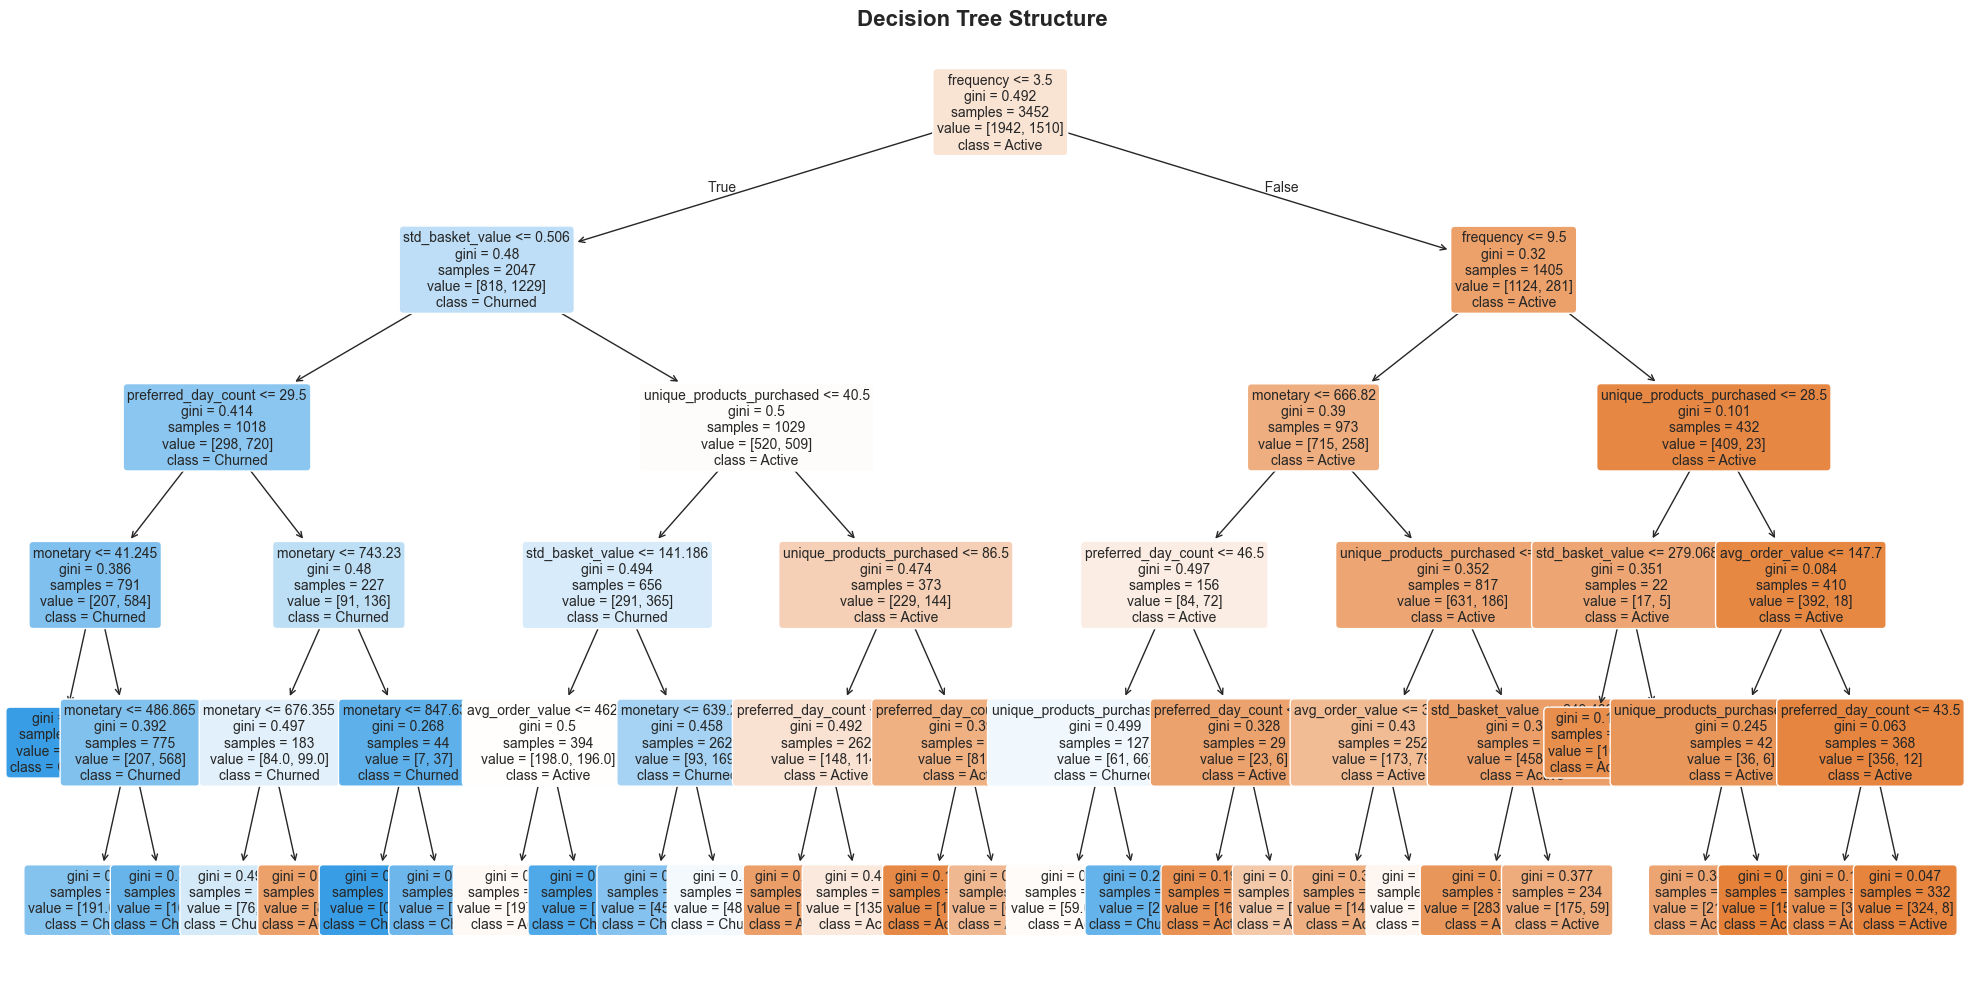

 Decision tree visualised


In [29]:
# Visualize tree structure
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X.columns,
          class_names=['Active', 'Churned'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Decision tree visualised")

## 3A.4 Decision Tree Feature Importance


 Top 10 Most Important Features (Decision Tree):
                  feature  importance
                frequency    0.673921
         std_basket_value    0.130851
                 monetary    0.074772
unique_products_purchased    0.063974
      preferred_day_count    0.037868
          avg_order_value    0.018614


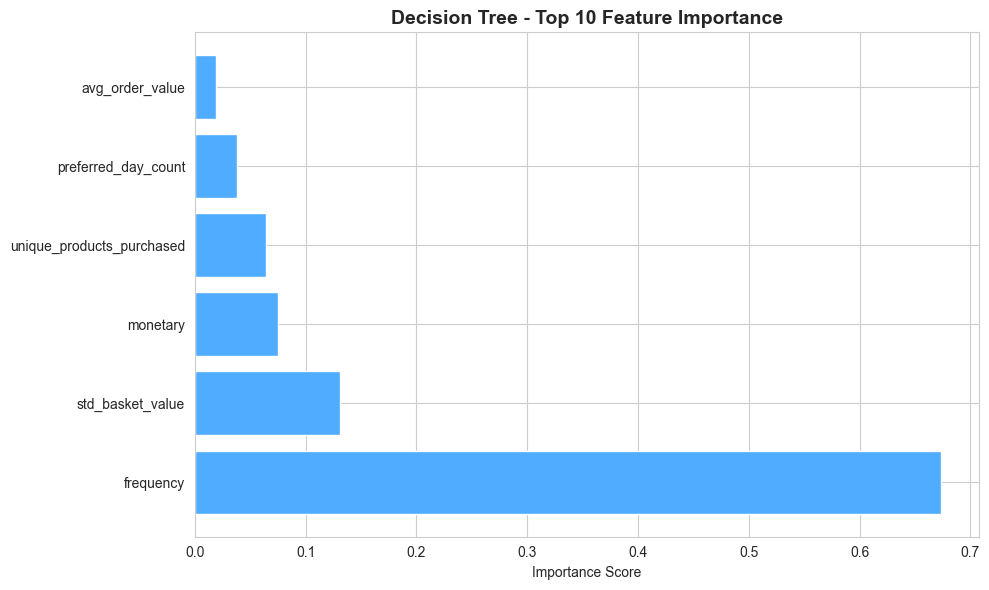

In [30]:
# Get feature importance
feature_importance_dt = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Most Important Features (Decision Tree):")
print(feature_importance_dt.head(10).to_string(index=False))

# Visualise
plt.figure(figsize=(10, 6))
top_10 = feature_importance_dt.head(10)
plt.barh(range(len(top_10)), top_10['importance'], color='#4facfe')
plt.yticks(range(len(top_10)), top_10['feature'])
plt.xlabel('Importance Score')
plt.title('Decision Tree - Top 10 Feature Importance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

## 3B.1 K-Means Clustering for Customer Segmentation

**Goal:** Group customers into segments based on RFM (Recency, Frequency, Monetary) scores

In [31]:
print("\n" + "="*60)
print("PART B: K-MEANS CLUSTERING FOR CUSTOMER SEGMENTATION")
print("="*60)

# Extract RFM features for clustering
rfm_features = ['recency', 'frequency', 'monetary']

# Check if RFM columns exist
rfm_available = all(col in customer_features.columns for col in rfm_features)

if rfm_available:
    print("\n RFM features found:")
    for col in rfm_features:
        print(f"   • {col}")
    
    # Prepare RFM data
    rfm_data = customer_features[rfm_features].copy()
    
    # Scale RFM features (K-Means is distance-based)
    scaler_rfm = StandardScaler()
    rfm_scaled = scaler_rfm.fit_transform(rfm_data)
    
    print(f"\n RFM data prepared:")
    print(f"   • {len(rfm_data):,} customers")
    print(f"   • 3 features (RFM)")
else:
    print("\n RFM features not found in expected format")
    print("   Available columns:", customer_features.columns.tolist())


PART B: K-MEANS CLUSTERING FOR CUSTOMER SEGMENTATION

 RFM features found:
   • recency
   • frequency
   • monetary

 RFM data prepared:
   • 4,315 customers
   • 3 features (RFM)


## 3B.2 Determine Optimal Number of Clusters

FINDING OPTIMAL NUMBER OF CLUSTERS


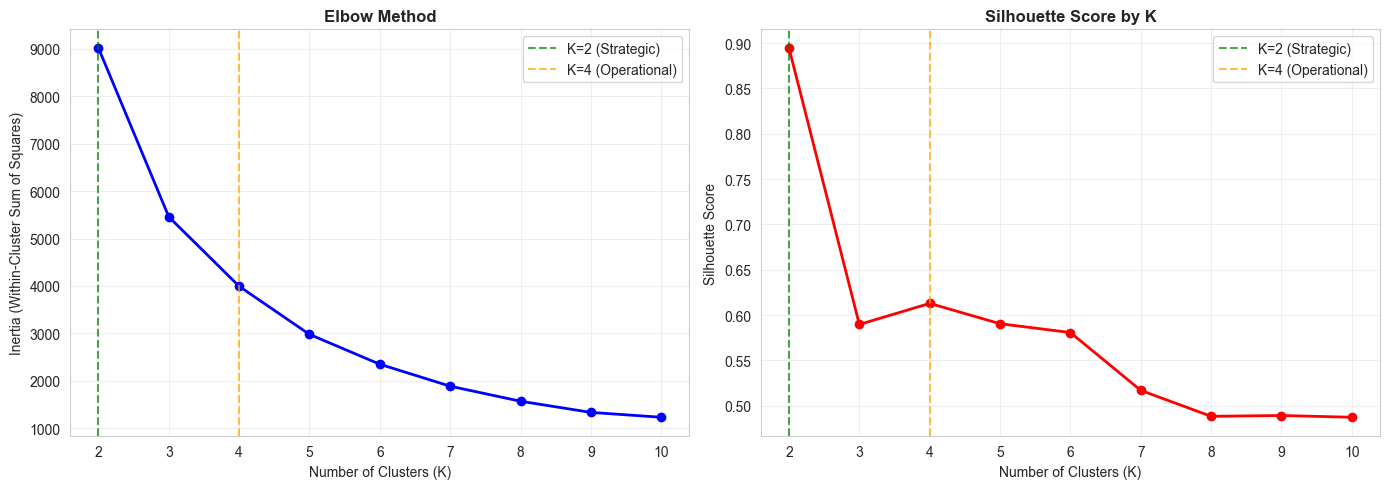


 Statistical Analysis:
   • Optimal K (by Silhouette Score): 2
   • Silhouette Score at K=2: 0.895

 Dual Segmentation Approach:
   • Strategic Segmentation: K=2 (High-level: VIPs vs Mass Market)
   • Operational Segmentation: K=4 (Detailed: Marketing campaigns)

 We'll use BOTH for comprehensive customer insights!


In [32]:
if rfm_available:
    print("="*60)
    print("FINDING OPTIMAL NUMBER OF CLUSTERS")
    print("="*60)
    
    # Test different numbers of clusters
    inertias = []
    silhouette_scores = []
    K_range = range(2, 11)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(rfm_scaled)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))
    
    # Plot Elbow Method
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow curve
    axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
    axes[0].set_title('Elbow Method', fontweight='bold')
    axes[0].grid(alpha=0.3)
    axes[0].axvline(x=2, color='green', linestyle='--', alpha=0.7, label='K=2 (Strategic)')
    axes[0].axvline(x=4, color='orange', linestyle='--', alpha=0.7, label='K=4 (Operational)')
    axes[0].legend()
    
    # Silhouette scores
    axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2)
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score by K', fontweight='bold')
    axes[1].grid(alpha=0.3)
    axes[1].axvline(x=2, color='green', linestyle='--', alpha=0.7, label='K=2 (Strategic)')
    axes[1].axvline(x=4, color='orange', linestyle='--', alpha=0.7, label='K=4 (Operational)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('kmeans_optimal_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Find statistically optimal K
    optimal_k = K_range[np.argmax(silhouette_scores)]
    print(f"\n Statistical Analysis:")
    print(f"   • Optimal K (by Silhouette Score): {optimal_k}")
    print(f"   • Silhouette Score at K={optimal_k}: {max(silhouette_scores):.3f}")
    
    print(f"\n Dual Segmentation Approach:")
    print(f"   • Strategic Segmentation: K=2 (High-level: VIPs vs Mass Market)")
    print(f"   • Operational Segmentation: K=4 (Detailed: Marketing campaigns)")
    print(f"\n We'll use BOTH for comprehensive customer insights!")

## 3B.3 Train K-Means Model

In [33]:

if rfm_available:
    print("="*60)
    print("TRAINING DUAL K-MEANS SEGMENTATION")
    print("="*60)
    
    # Strategic Segmentation (K=2)
    print("\n Strategic Segmentation (K=2):")
    kmeans_strategic = KMeans(n_clusters=2, random_state=42, n_init=10)
    customer_features['strategic_segment'] = kmeans_strategic.fit_predict(rfm_scaled)
    
    print(f"    K=2 model trained (VIP vs Mass Market)")
    
    # Operational Segmentation (K=4)
    print("\n Operational Segmentation (K=4):")
    kmeans_operational = KMeans(n_clusters=4, random_state=42, n_init=10)
    customer_features['operational_segment'] = kmeans_operational.fit_predict(rfm_scaled)
    
    print(f"    K=4 model trained (Detailed marketing segments)")
    
    # Also keep 'cluster' column for backward compatibility (use K=4)
    customer_features['cluster'] = customer_features['operational_segment']
    
    print(f"\n Dual K-Means clustering complete!")
    print(f"   • Strategic segments: 2 (for executives)")
    print(f"   • Operational segments: 4 (for marketing)")
    
    # Strategic Segment Distribution
    print(f"\n Strategic Segment Distribution (K=2):")
    strategic_counts = customer_features['strategic_segment'].value_counts().sort_index()
    for segment, count in strategic_counts.items():
        pct = count / len(customer_features) * 100
        print(f"   • Segment {segment}: {count:,} customers ({pct:.1f}%)")
    
    # Operational Cluster Distribution
    print(f"\n Operational Cluster Distribution (K=4):")
    operational_counts = customer_features['operational_segment'].value_counts().sort_index()
    for cluster, count in operational_counts.items():
        pct = count / len(customer_features) * 100
        print(f"   • Cluster {cluster}: {count:,} customers ({pct:.1f}%)")

TRAINING DUAL K-MEANS SEGMENTATION

 Strategic Segmentation (K=2):
    K=2 model trained (VIP vs Mass Market)

 Operational Segmentation (K=4):
    K=4 model trained (Detailed marketing segments)

 Dual K-Means clustering complete!
   • Strategic segments: 2 (for executives)
   • Operational segments: 4 (for marketing)

 Strategic Segment Distribution (K=2):
   • Segment 0: 4,289 customers (99.4%)
   • Segment 1: 26 customers (0.6%)

 Operational Cluster Distribution (K=4):
   • Cluster 0: 3,138 customers (72.7%)
   • Cluster 1: 1,061 customers (24.6%)
   • Cluster 2: 6 customers (0.1%)
   • Cluster 3: 110 customers (2.5%)


## 3B.4 Profile Customer Segments

In [34]:
if rfm_available:

    print("="*60)
    print("CUSTOMER SEGMENT PROFILES - DUAL APPROACH")
    print("="*60)

    # ==========================================================
    # STRATEGIC SEGMENTATION (K=2)
    # ==========================================================
    print("\n" + "="*60)
    print(" STRATEGIC SEGMENTATION (K=2)")
    print("="*60)

    strategic_profiles = customer_features.groupby('strategic_segment')[rfm_features].mean()
    strategic_profiles['customer_count'] = customer_features.groupby('strategic_segment').size()
    strategic_profiles['total_revenue'] = customer_features.groupby('strategic_segment')['monetary'].sum()
    strategic_profiles['churn_rate'] = customer_features.groupby('strategic_segment')['churned'].mean() * 100

    # Revenue share
    strategic_profiles['revenue_pct'] = (
        strategic_profiles['total_revenue'] /
        strategic_profiles['total_revenue'].sum() * 100
    )

    print("\n Strategic Profiles (VIP vs Mass Market):")
    print(strategic_profiles.to_string())

    # Dynamic VIP threshold (top spenders)
    vip_threshold = strategic_profiles['monetary'].quantile(0.75)

    def assign_strategic_name(row):
        if row['monetary'] >= vip_threshold:
            return "VIP Champions"
        else:
            return "Mass Market"

    strategic_profiles['segment_name'] = strategic_profiles.apply(assign_strategic_name, axis=1)

    print("\n Strategic Segment Names:")
    print(
        strategic_profiles[
            ['segment_name','customer_count','total_revenue','revenue_pct','churn_rate']
        ].to_string()
    )

    # ==========================================================
    # OPERATIONAL SEGMENTATION (K=4)
    # ==========================================================
    print("\n" + "="*60)
    print(" OPERATIONAL SEGMENTATION (K=4)")
    print("="*60)

    operational_profiles = customer_features.groupby('operational_segment')[rfm_features].mean()
    operational_profiles['customer_count'] = customer_features.groupby('operational_segment').size()
    operational_profiles['total_revenue'] = customer_features.groupby('operational_segment')['monetary'].sum()
    operational_profiles['churn_rate'] = customer_features.groupby('operational_segment')['churned'].mean() * 100

    print("\n Operational Profiles (Detailed Marketing Segments):")
    print(operational_profiles.to_string())

    # ----------------------------------------------------------
    # Rank clusters based on RFM quality
    # Best customers: low recency, high frequency, high monetary
    # ----------------------------------------------------------
    ranked_profiles = operational_profiles.sort_values(
        by=['recency','monetary','frequency'],
        ascending=[True, False, False]
    )

    segment_labels = [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "Lost Customers"
    ]

    ranked_profiles['segment_name'] = segment_labels[:len(ranked_profiles)]

    # Restore cluster order
    operational_profiles = ranked_profiles.sort_index()

    print("\n Operational Segment Names:")
    print(
        operational_profiles[
            ['segment_name','customer_count','churn_rate']
        ].to_string()
    )

    # Store segment profiles for later compatibility
    segment_profiles = operational_profiles

CUSTOMER SEGMENT PROFILES - DUAL APPROACH

 STRATEGIC SEGMENTATION (K=2)

 Strategic Profiles (VIP vs Mass Market):
                     recency  frequency      monetary  customer_count  total_revenue  churn_rate  revenue_pct
strategic_segment                                                                                            
0                  90.862206   4.646304   1477.151274            4289    6335501.814    43.99627    76.233732
1                   5.923077  83.269231  75966.387308              26    1975126.070     0.00000    23.766268

 Strategic Segment Names:
                    segment_name  customer_count  total_revenue  revenue_pct  churn_rate
strategic_segment                                                                       
0                    Mass Market            4289    6335501.814    76.233732    43.99627
1                  VIP Champions              26    1975126.070    23.766268     0.00000

 OPERATIONAL SEGMENTATION (K=4)

 Operational Profiles (Deta

## 3B.5 Visualise Customer Segments

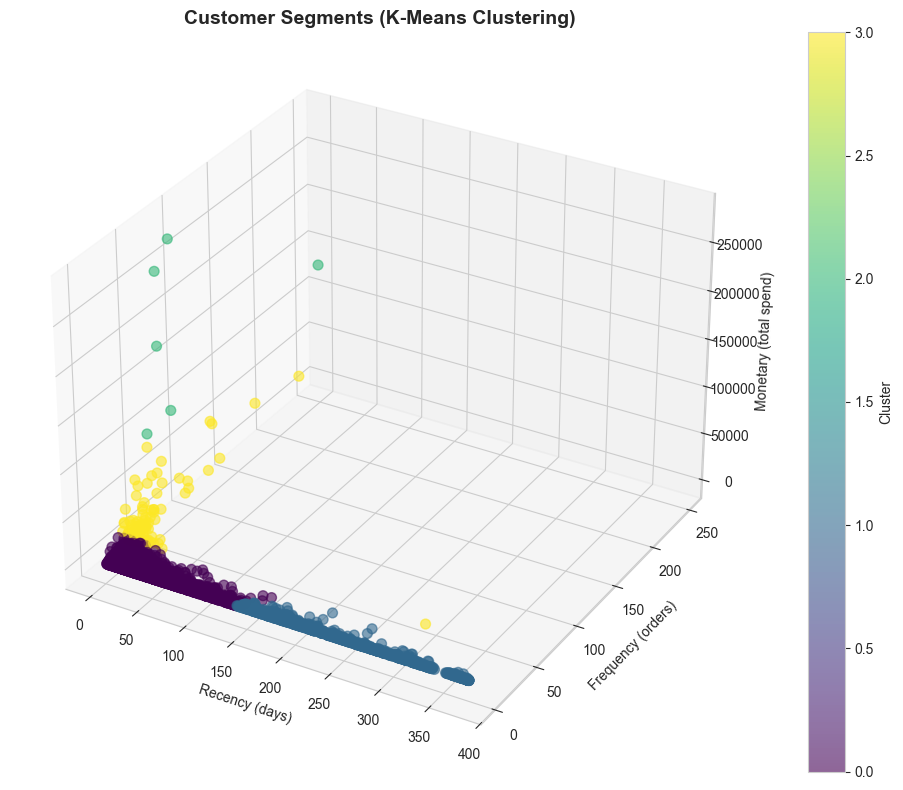

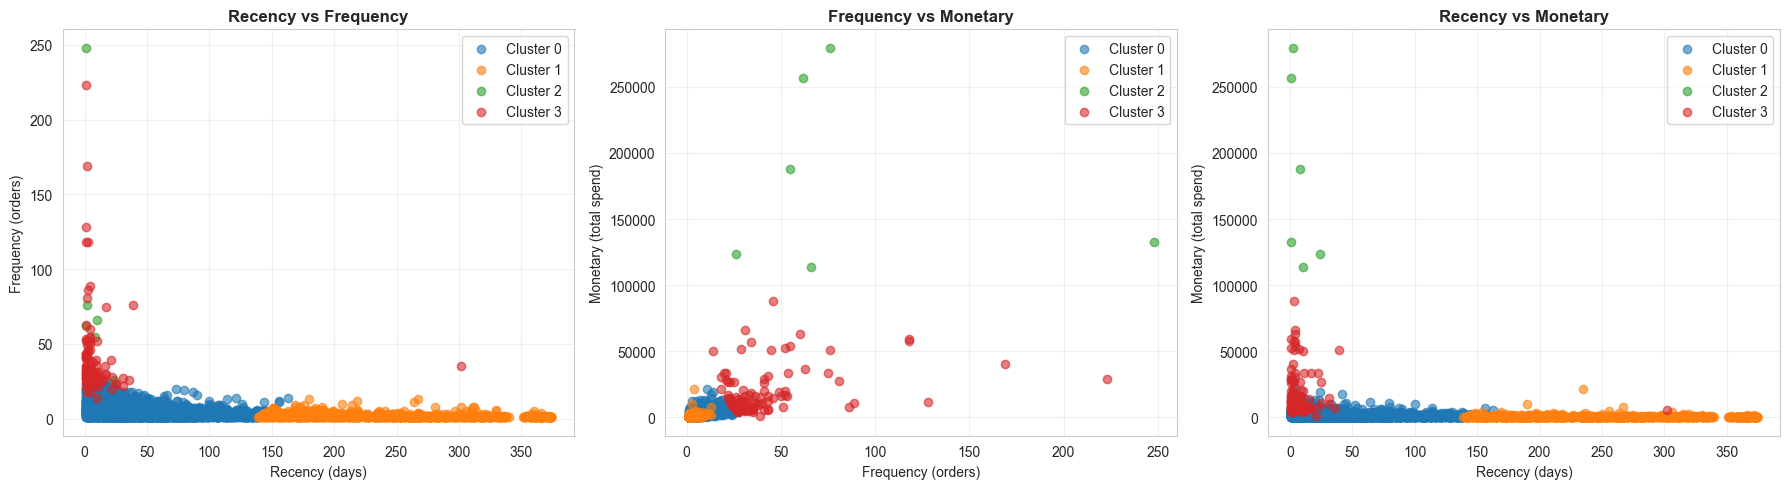


 Segment visualisations created


In [35]:
if rfm_available:
    # 3D visualisation of clusters
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(
        customer_features['recency'],
        customer_features['frequency'],
        customer_features['monetary'],
        c=customer_features['cluster'],
        cmap='viridis',
        s=50,
        alpha=0.6
    )
    
    ax.set_xlabel('Recency (days)')
    ax.set_ylabel('Frequency (orders)')
    ax.set_zlabel('Monetary (total spend)')
    ax.set_title('Customer Segments (K-Means Clustering)', fontweight='bold', fontsize=14)
    
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.savefig('customer_segments_3d.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2D views
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Recency vs Frequency
    for cluster in customer_features['cluster'].unique():
        mask = customer_features['cluster'] == cluster
        axes[0].scatter(
            customer_features.loc[mask, 'recency'],
            customer_features.loc[mask, 'frequency'],
            label=f'Cluster {cluster}',
            alpha=0.6
        )
    axes[0].set_xlabel('Recency (days)')
    axes[0].set_ylabel('Frequency (orders)')
    axes[0].set_title('Recency vs Frequency', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Frequency vs Monetary
    for cluster in customer_features['cluster'].unique():
        mask = customer_features['cluster'] == cluster
        axes[1].scatter(
            customer_features.loc[mask, 'frequency'],
            customer_features.loc[mask, 'monetary'],
            label=f'Cluster {cluster}',
            alpha=0.6
        )
    axes[1].set_xlabel('Frequency (orders)')
    axes[1].set_ylabel('Monetary (total spend)')
    axes[1].set_title('Frequency vs Monetary', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Recency vs Monetary
    for cluster in customer_features['cluster'].unique():
        mask = customer_features['cluster'] == cluster
        axes[2].scatter(
            customer_features.loc[mask, 'recency'],
            customer_features.loc[mask, 'monetary'],
            label=f'Cluster {cluster}',
            alpha=0.6
        )
    axes[2].set_xlabel('Recency (days)')
    axes[2].set_ylabel('Monetary (total spend)')
    axes[2].set_title('Recency vs Monetary', fontweight='bold')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('customer_segments_2d_views.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n Segment visualisations created")

## 3B.6 Save Segment Assignments

In [36]:
if rfm_available:
    # Save customer segments
    segment_output = customer_features[['customer_id', 'cluster', 'recency', 'frequency', 'monetary', 'churned']].copy()
    segment_output.to_csv('customer_segments.csv', index=False)
    
    print(" Customer segments saved: customer_segments.csv")
    print(f"   • {len(segment_output):,} customers with cluster assignments")

 Customer segments saved: customer_segments.csv
   • 4,315 customers with cluster assignments


## Step 3 Summary

In [37]:
print("\n" + "="*60)
print(" STEP 3 COMPLETE: DECISION TREE & K-MEANS CLUSTERING")
print("="*60)
print("""
What We Accomplished:

Part A - Decision Tree:
   ✓ Trained Decision Tree classifier
   ✓ Evaluated performance metrics
   ✓ Visualised tree structure
   ✓ Analysed feature importance

Part B - K-Means Clustering:
   ✓ Determined optimal number of clusters (Elbow + Silhouette)
   ✓ Segmented customers based on RFM scores
   ✓ Profiled each segment (avg RFM, size, churn rate)
   ✓ Created 3D and 2D visualisations
   ✓ Saved segment assignments

Models Trained So Far:
""")
for model_name, metrics in model_results.items():
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"   • {metric}: {value:.4f}")

print("\nNext STEP 4: Random Forest & Model Comparison")


 STEP 3 COMPLETE: DECISION TREE & K-MEANS CLUSTERING

What We Accomplished:

Part A - Decision Tree:
   ✓ Trained Decision Tree classifier
   ✓ Evaluated performance metrics
   ✓ Visualised tree structure
   ✓ Analysed feature importance

Part B - K-Means Clustering:
   ✓ Determined optimal number of clusters (Elbow + Silhouette)
   ✓ Segmented customers based on RFM scores
   ✓ Profiled each segment (avg RFM, size, churn rate)
   ✓ Created 3D and 2D visualisations
   ✓ Saved segment assignments

Models Trained So Far:


Logistic Regression:
   • Accuracy: 0.6837
   • Precision: 0.5992
   • Recall: 0.8329
   • F1-Score: 0.6970
   • ROC-AUC: 0.7598

Decision Tree:
   • Accuracy: 0.6663
   • Precision: 0.6320
   • Recall: 0.5650
   • F1-Score: 0.5966
   • ROC-AUC: 0.7435

Next STEP 4: Random Forest & Model Comparison


---
<a id='Step-4'></a>
# Step 4: Random Forest & Comprehensive Model Comparison

## Objectives:
- Train Random Forest ensemble model
- Perform cross-validation
- Compare all 3 classification models
- Analyse churn patterns within customer segments
- Select best model for business use

## 4.1 Train Random Forest Model

In [38]:
print("="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_model.fit(X_train, y_train)

print("\n Random Forest trained!")
print(f"   • Number of trees: {rf_model.n_estimators}")
print(f"   • Max depth: {rf_model.max_depth}")

TRAINING RANDOM FOREST MODEL

 Random Forest trained!
   • Number of trees: 100
   • Max depth: 10


## 4.2 Evaluate Random Forest

In [39]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("="*60)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("="*60)
print(f"\n Model Performance:")
print(f"   • Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"   • Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"   • Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"   • F1-Score:  {f1_rf:.4f}")
print(f"   • ROC-AUC:   {roc_auc_rf:.4f}")

# Store results
model_results['Random Forest'] = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf,
    'ROC-AUC': roc_auc_rf
}

RANDOM FOREST - PERFORMANCE METRICS

 Model Performance:
   • Accuracy:  0.6906 (69.06%)
   • Precision: 0.6418 (64.18%)
   • Recall:    0.6605 (66.05%)
   • F1-Score:  0.6510
   • ROC-AUC:   0.7610


## 4.3 Cross-Validation

In [40]:
print("="*60)
print("5-FOLD CROSS-VALIDATION")
print("="*60)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f"\n Cross-Validation Results:")
print(f"   • Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"   • Mean accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"   • Min accuracy: {cv_scores.min():.4f}")
print(f"   • Max accuracy: {cv_scores.max():.4f}")

5-FOLD CROSS-VALIDATION

 Cross-Validation Results:
   • Fold scores: ['0.6527', '0.7004', '0.6841', '0.7246', '0.7174']
   • Mean accuracy: 0.6958 (±0.0258)
   • Min accuracy: 0.6527
   • Max accuracy: 0.7246


## 4.4 Random Forest Feature Importance


 Top 10 Most Important Features (Random Forest):
                  feature  importance
                frequency    0.252464
unique_products_purchased    0.197899
         std_basket_value    0.171518
                 monetary    0.167316
      preferred_day_count    0.106020
          avg_order_value    0.104782


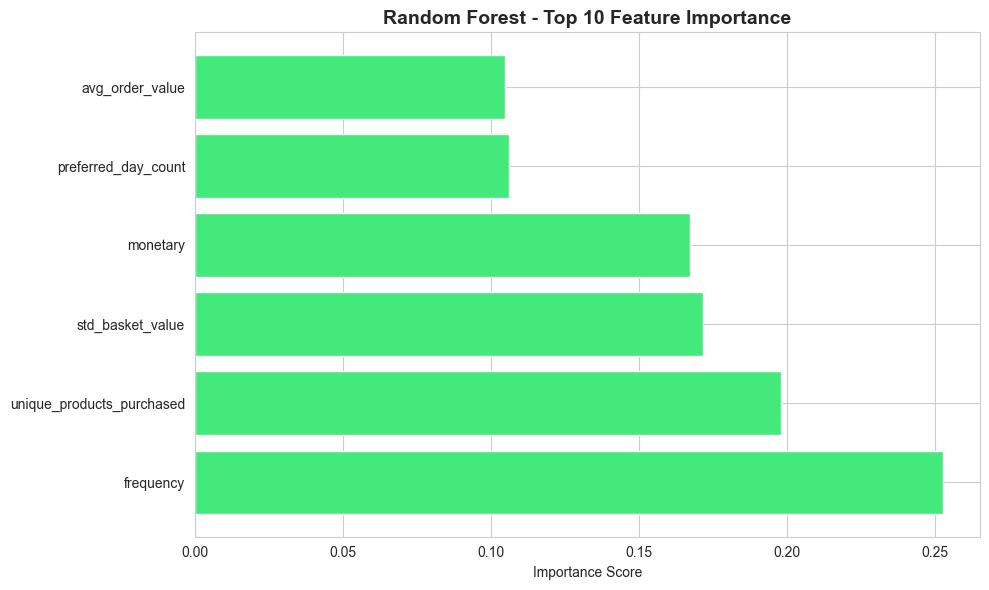

In [41]:
# Get feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
top_10 = feature_importance_rf.head(10)
plt.barh(range(len(top_10)), top_10['importance'], color='#43e97b')
plt.yticks(range(len(top_10)), top_10['feature'])
plt.xlabel('Importance Score')
plt.title('Random Forest - Top 10 Feature Importance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.5 Comprehensive Model Comparison

COMPREHENSIVE MODEL COMPARISON

 All Models Performance:
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.683662   0.599237  0.832891  0.697003  0.759805
Decision Tree        0.666280   0.632047  0.564987  0.596639  0.743532
Random Forest        0.690614   0.641753  0.660477  0.650980  0.761011


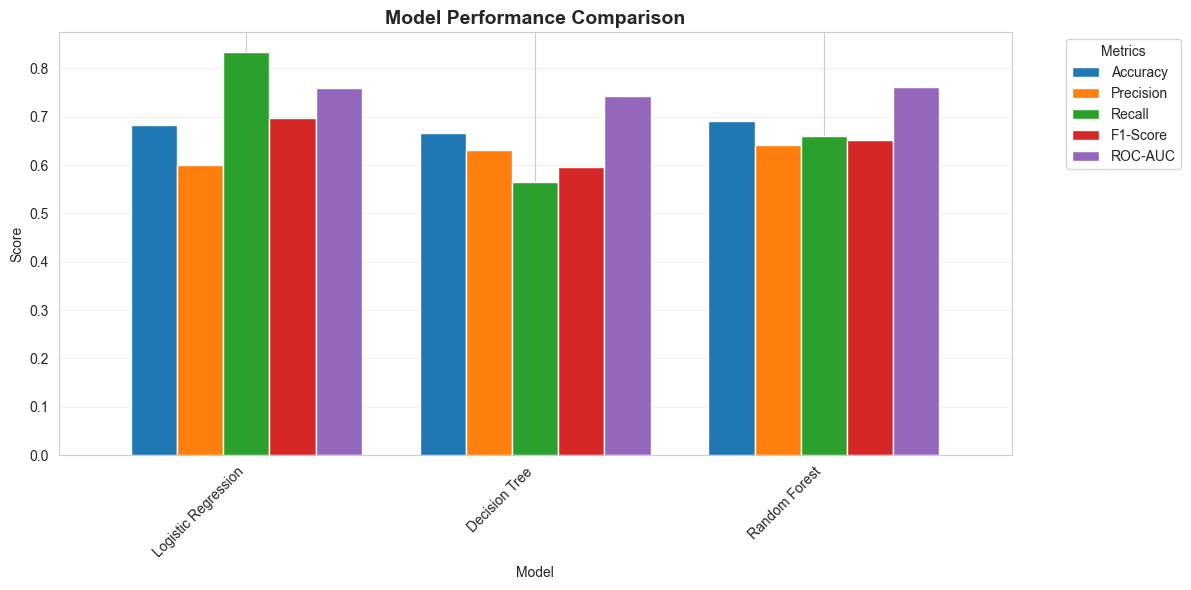


 Best Model by Metric:
   • Accuracy: Random Forest (0.6906)
   • Precision: Random Forest (0.6418)
   • Recall: Logistic Regression (0.8329)
   • F1-Score: Logistic Regression (0.6970)
   • ROC-AUC: Random Forest (0.7610)


In [42]:
print("="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame(model_results).T
print("\n All Models Performance:")
print(comparison_df.to_string())

# Visualize comparison
comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Model Performance Comparison', fontweight='bold', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

# Find best model for each metric
print("\n Best Model by Metric:")
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"   • {metric}: {best_model} ({best_score:.4f})")

## 4.6 Churn Analysis by Customer Segment

CHURN ANALYSIS BY CUSTOMER SEGMENT

 Churn Rate by Segment:
         churned_count  churn_rate  total_customers  avg_monetary  avg_recency  avg_frequency
cluster                                                                                      
0                  825        26.3             3138      1489.703       41.079          4.824
1                 1061       100.0             1061       484.669      244.959          1.838
2                    0         0.0                6    182181.982        7.667         88.833
3                    1         0.9              110     18441.961        9.182         40.664


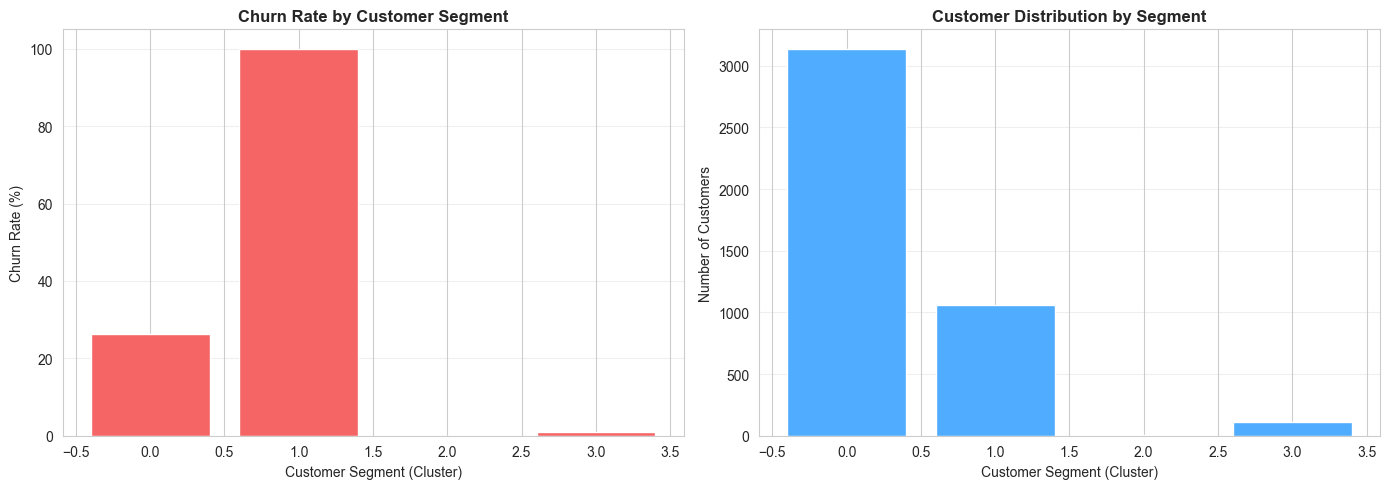


 Key Insights:
   • Highest churn: Segment 1 (100.0%)
   • Lowest churn: Segment 2 (0.0%)


In [43]:
if rfm_available and 'cluster' in customer_features.columns:
    print("="*60)
    print("CHURN ANALYSIS BY CUSTOMER SEGMENT")
    print("="*60)
    
    # Analyze churn rate per segment
    segment_churn = customer_features.groupby('cluster').agg({
        'churned': ['sum', 'mean', 'count'],
        'monetary': 'mean',
        'recency': 'mean',
        'frequency': 'mean'
    }).round(3)
    
    segment_churn.columns = ['churned_count', 'churn_rate', 'total_customers', 
                              'avg_monetary', 'avg_recency', 'avg_frequency']
    segment_churn['churn_rate'] = segment_churn['churn_rate'] * 100
    
    print("\n Churn Rate by Segment:")
    print(segment_churn.to_string())
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Churn rate by cluster
    axes[0].bar(segment_churn.index, segment_churn['churn_rate'], color='#f56565')
    axes[0].set_xlabel('Customer Segment (Cluster)')
    axes[0].set_ylabel('Churn Rate (%)')
    axes[0].set_title('Churn Rate by Customer Segment', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Customer count by cluster
    axes[1].bar(segment_churn.index, segment_churn['total_customers'], color='#4facfe')
    axes[1].set_xlabel('Customer Segment (Cluster)')
    axes[1].set_ylabel('Number of Customers')
    axes[1].set_title('Customer Distribution by Segment', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('churn_by_segment.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n Key Insights:")
    highest_churn_segment = segment_churn['churn_rate'].idxmax()
    highest_churn_rate = segment_churn['churn_rate'].max()
    print(f"   • Highest churn: Segment {highest_churn_segment} ({highest_churn_rate:.1f}%)")
    
    lowest_churn_segment = segment_churn['churn_rate'].idxmin()
    lowest_churn_rate = segment_churn['churn_rate'].min()
    print(f"   • Lowest churn: Segment {lowest_churn_segment} ({lowest_churn_rate:.1f}%)")

## Step 4 Summary

In [44]:
print("\n" + "="*60)
print(" STEP 4 COMPLETE: RANDOM FOREST & MODEL COMPARISON")
print("="*60)
print("""
What We Accomplished:
   ✓ Trained Random Forest ensemble model
   ✓ Performed 5-fold cross-validation
   ✓ Analysed feature importance (top 10 features)
   ✓ Compared all 3 models comprehensively
   ✓ Analysed churn patterns within customer segments
   ✓ Identified best-performing model

Final Model Rankings:
""")
print(comparison_df.to_string())
print("\nNext STEP 5: Business Recommendations & Final Report")


 STEP 4 COMPLETE: RANDOM FOREST & MODEL COMPARISON

What We Accomplished:
   ✓ Trained Random Forest ensemble model
   ✓ Performed 5-fold cross-validation
   ✓ Analysed feature importance (top 10 features)
   ✓ Compared all 3 models comprehensively
   ✓ Analysed churn patterns within customer segments
   ✓ Identified best-performing model

Final Model Rankings:

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.683662   0.599237  0.832891  0.697003  0.759805
Decision Tree        0.666280   0.632047  0.564987  0.596639  0.743532
Random Forest        0.690614   0.641753  0.660477  0.650980  0.761011

Next STEP 5: Business Recommendations & Final Report


---
<a id='Step-5'></a>
# Step 5: Business Recommendations & Final Report

## Objectives:
- Create customer risk segmentation
- Calculate business impact (potential revenue loss)
- Generate segment-specific retention recommendations
- Create executive presentation
- Document complete ML workflow

## 5.1 Customer Risk Segmentation

CUSTOMER RISK SEGMENTATION

 Using Random Forest as final model

 Customer Risk Distribution:
   • Medium Risk: 2,087 customers (48.4%)
   • Low Risk: 1,411 customers (32.7%)
   • High Risk: 817 customers (18.9%)


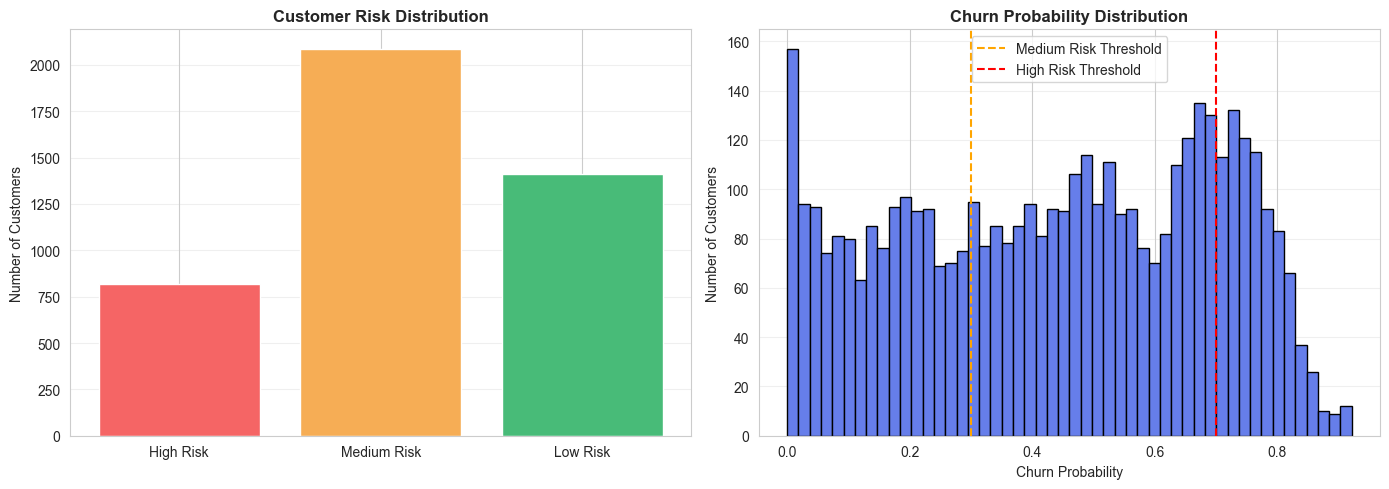

In [45]:
print("="*60)
print("CUSTOMER RISK SEGMENTATION")
print("="*60)

# Select best model (typically Random Forest or the one with highest F1/ROC-AUC)
#best_model = log_reg
best_model = rf_model
print(f"\n Using Random Forest as final model")

# Get churn probabilities for ALL customers
all_churn_probabilities = best_model.predict_proba(X)[:, 1]
customer_features['churn_probability'] = all_churn_probabilities

# Create risk segments
def assign_risk_level(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

customer_features['risk_level'] = customer_features['churn_probability'].apply(assign_risk_level)

# Risk distribution
risk_counts = customer_features['risk_level'].value_counts()
risk_pct = customer_features['risk_level'].value_counts(normalize=True) * 100

print(f"\n Customer Risk Distribution:")
for risk, count in risk_counts.items():
    pct = risk_pct[risk]
    print(f"   • {risk}: {count:,} customers ({pct:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk distribution bar chart
colors_risk = {'High Risk': '#f56565', 'Medium Risk': '#f6ad55', 'Low Risk': '#48bb78'}
risk_counts_ordered = risk_counts.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
bars = axes[0].bar(range(len(risk_counts_ordered)), risk_counts_ordered.values,
                   color=[colors_risk[x] for x in risk_counts_ordered.index])
axes[0].set_xticks(range(len(risk_counts_ordered)))
axes[0].set_xticklabels(risk_counts_ordered.index, rotation=0)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Risk Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Churn probability distribution
axes[1].hist(customer_features['churn_probability'], bins=50, color='#667eea', edgecolor='black')
axes[1].axvline(x=0.3, color='orange', linestyle='--', label='Medium Risk Threshold')
axes[1].axvline(x=0.7, color='red', linestyle='--', label='High Risk Threshold')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Churn Probability Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('customer_risk_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.2 Business Impact Analysis

In [46]:
print("="*60)
print("BUSINESS IMPACT ANALYSIS")
print("="*60)

# Calculate potential revenue loss
high_risk_customers = customer_features[customer_features['risk_level'] == 'High Risk']
medium_risk_customers = customer_features[customer_features['risk_level'] == 'Medium Risk']

# Potential revenue at risk (assuming customers churn)
high_risk_revenue = high_risk_customers['monetary'].sum()
medium_risk_revenue = medium_risk_customers['monetary'].sum()
total_revenue_at_risk = high_risk_revenue + medium_risk_revenue

print(f"\n Revenue at Risk:")
print(f"   • High Risk customers: ${high_risk_revenue:,.2f}")
print(f"   • Medium Risk customers: ${medium_risk_revenue:,.2f}")
print(f"   • Total at risk: ${total_revenue_at_risk:,.2f}")

# Average customer lifetime value by risk level
risk_clv = customer_features.groupby('risk_level')['monetary'].agg(['mean', 'median', 'sum'])
print(f"\n Customer Lifetime Value by Risk Level:")
print(risk_clv.to_string())

# If clustering was done, analyze by segment
if 'cluster' in customer_features.columns:
    print(f"\n Business Impact by Customer Segment:")
    segment_impact = customer_features.groupby(['cluster', 'risk_level']).agg({
        'customer_id': 'count',
        'monetary': 'sum'
    }).rename(columns={'customer_id': 'customer_count', 'monetary': 'revenue_at_risk'})
    print(segment_impact.to_string())

BUSINESS IMPACT ANALYSIS

 Revenue at Risk:
   • High Risk customers: $300,335.27
   • Medium Risk customers: $1,527,949.42
   • Total at risk: $1,828,284.69

 Customer Lifetime Value by Risk Level:
                    mean   median          sum
risk_level                                    
High Risk     367.607431   295.93   300335.271
Low Risk     4594.148257  2140.22  6482343.191
Medium Risk   732.127179   473.02  1527949.422

 Business Impact by Customer Segment:
                     customer_count  revenue_at_risk
cluster risk_level                                  
0       High Risk               353       152997.351
        Low Risk               1263      3304001.281
        Medium Risk            1522      1217688.011
1       High Risk               464       147337.920
        Low Risk                 32        56634.260
        Medium Risk             565       310261.411
2       Low Risk                  6      1093091.890
3       Low Risk                110      2028615.7

## 5.3 Retention Strategy Recommendations

In [47]:
print("="*60)
print("RETENTION STRATEGY RECOMMENDATIONS")
print("="*60)

print("""
 SEGMENT-SPECIFIC RETENTION STRATEGIES:

 HIGH RISK CUSTOMERS (Churn Probability > 70%):
   Strategy: URGENT INTERVENTION
   Actions:
   • Immediate personal outreach (phone call or personalised email)
   • Offer exclusive win-back discount (15-20% off next purchase)
   • Conduct exit survey to understand pain points
   • VIP customer service with dedicated account manager
   • Limited-time free shipping or product bundle offers
   
   Priority: Target within 7 days
   Expected Cost: High (personalised campaigns)
   Expected ROI: Very High (saving high-value customers)

 MEDIUM RISK CUSTOMERS (Churn Probability 30-70%):
   Strategy: PROACTIVE ENGAGEMENT
   Actions:
   • Send re-engagement email campaign
   • Highlight new products based on purchase history
   • Offer loyalty rewards or points multiplier
   • Time-sensitive promotions (48-72 hour flash sales)
   • Educational content (how-to guides, product tips)
   
   Priority: Target within 14-30 days
   Expected Cost: Medium (automated campaigns with some personalisation)
   Expected ROI: High (preventing churn before it happens)

 LOW RISK CUSTOMERS (Churn Probability < 30%):
   Strategy: NURTURE & GROW
   Actions:
   • Standard email marketing campaigns
   • Cross-sell and upsell recommendations
   • Referral program incentives
   • Early access to new products
   • Build brand loyalty through content marketing
   
   Priority: Ongoing monthly engagement
   Expected Cost: Low (automated campaigns)
   Expected ROI: Medium (maximising customer lifetime value)

""")

# Calculate recommended budget allocation
print(" RECOMMENDED RETENTION BUDGET ALLOCATION:")
total_customers = len(customer_features)
high_risk_pct = len(high_risk_customers) / total_customers * 100
medium_risk_pct = len(medium_risk_customers) / total_customers * 100

print(f"\n   If total retention budget = $100,000:")
print(f"   • High Risk ({high_risk_pct:.1f}% of customers): $50,000 (50%)")
print(f"   • Medium Risk ({medium_risk_pct:.1f}% of customers): $35,000 (35%)")
print(f"   • Low Risk: $15,000 (15%)")
print(f"\n   Rationale: Focus budget where churn risk is highest")

RETENTION STRATEGY RECOMMENDATIONS

 SEGMENT-SPECIFIC RETENTION STRATEGIES:

 HIGH RISK CUSTOMERS (Churn Probability > 70%):
   Strategy: URGENT INTERVENTION
   Actions:
   • Immediate personal outreach (phone call or personalised email)
   • Offer exclusive win-back discount (15-20% off next purchase)
   • Conduct exit survey to understand pain points
   • VIP customer service with dedicated account manager
   • Limited-time free shipping or product bundle offers

   Priority: Target within 7 days
   Expected Cost: High (personalised campaigns)
   Expected ROI: Very High (saving high-value customers)

 MEDIUM RISK CUSTOMERS (Churn Probability 30-70%):
   Strategy: PROACTIVE ENGAGEMENT
   Actions:
   • Send re-engagement email campaign
   • Highlight new products based on purchase history
   • Offer loyalty rewards or points multiplier
   • Time-sensitive promotions (48-72 hour flash sales)
   • Educational content (how-to guides, product tips)

   Priority: Target within 14-30 days
  

## 5.4 Top Churn Drivers (What to Address)

In [48]:
print("="*60)
print("TOP CHURN DRIVERS (FEATURES TO ADDRESS)")
print("="*60)

print("\n Based on feature importance analysis:")
print(feature_importance_rf.head(5).to_string(index=False))

print("""
\n ACTIONABLE RECOMMENDATIONS BY FEATURE:

If 'days_since_last_purchase' (Recency) is top feature:
   → Set up automated triggers: send re-engagement email at 30, 60, 90 days
   → Create "We miss you" campaigns
   
If 'frequency' is top feature:
   → Incentivise repeat purchases with loyalty programs
   → Offer subscription or auto-delivery options
   
If 'monetary' (total spend) is top feature:
   → Segment by spend level and offer tiered rewards
   → Provide VIP treatment to high-spenders
   
If 'avg_basket_value' is top feature:
   → Encourage larger orders with free shipping thresholds
   → Bundle products or "complete the look" suggestions
""")

TOP CHURN DRIVERS (FEATURES TO ADDRESS)

 Based on feature importance analysis:
                  feature  importance
                frequency    0.252464
unique_products_purchased    0.197899
         std_basket_value    0.171518
                 monetary    0.167316
      preferred_day_count    0.106020


 ACTIONABLE RECOMMENDATIONS BY FEATURE:

If 'days_since_last_purchase' (Recency) is top feature:
   → Set up automated triggers: send re-engagement email at 30, 60, 90 days
   → Create "We miss you" campaigns

If 'frequency' is top feature:
   → Incentivise repeat purchases with loyalty programs
   → Offer subscription or auto-delivery options

If 'monetary' (total spend) is top feature:
   → Segment by spend level and offer tiered rewards
   → Provide VIP treatment to high-spenders

If 'avg_basket_value' is top feature:
   → Encourage larger orders with free shipping thresholds
   → Bundle products or "complete the look" suggestions



## 5.5 Save Final Outputs

In [49]:
print("="*60)
print("SAVING FINAL OUTPUTS")
print("="*60)

# Save customer risk segmentation with cluster info
output_columns = ['customer_id', 'churn_probability', 'risk_level', 'churned',
                  'recency', 'frequency', 'monetary']
if 'cluster' in customer_features.columns:
    output_columns.insert(3, 'cluster')

customer_risk_output = customer_features[output_columns].copy()
customer_risk_output.to_csv('customer_churn_predictions.csv', index=False)
print("\n Saved: customer_churn_predictions.csv")

# Save model comparison
comparison_df.to_csv('model_comparison_results.csv')
print(" Saved: model_comparison_results.csv")

# Save feature importance
feature_importance_rf.to_csv('feature_importance_final.csv', index=False)
print(" Saved: feature_importance_final.csv")

print(f"\n Total files saved: 3")

SAVING FINAL OUTPUTS

 Saved: customer_churn_predictions.csv
 Saved: model_comparison_results.csv
 Saved: feature_importance_final.csv

 Total files saved: 3


## 5.6 Executive Summary

In [50]:
print("="*60)
print("EXECUTIVE SUMMARY - Phase 3")
print("="*60)

summary = f"""
PROJECT: Customer Churn Prediction & Segmentation
TIMEFRAME: Phase 3
DATE: {datetime.now().strftime('%B %d, %Y')}

{'='*60}
KEY FINDINGS
{'='*60}

1. CUSTOMER BASE:
   • Total customers analyzed: {len(customer_features):,}
   • Current churn rate: {customer_features['churned'].mean()*100:.1f}%
   • Active customers: {(customer_features['churned']==0).sum():,}
   • Churned customers: {(customer_features['churned']==1).sum():,}

2. RISK DISTRIBUTION:
   • High Risk (>70% churn probability): {len(high_risk_customers):,} customers ({len(high_risk_customers)/len(customer_features)*100:.1f}%)
   • Medium Risk (30-70%): {len(medium_risk_customers):,} customers ({len(medium_risk_customers)/len(customer_features)*100:.1f}%)
   • Low Risk (<30%): {(customer_features['risk_level']=='Low Risk').sum():,} customers

3. BUSINESS IMPACT:
   • Revenue at risk (High + Medium): ${total_revenue_at_risk:,.2f}
   • Average value per high-risk customer: ${high_risk_customers['monetary'].mean():,.2f}

4. MODEL PERFORMANCE:
   • Best model: Random Forest
   • Accuracy: {accuracy_rf:.1%}
   • Precision: {precision_rf:.1%} (of predicted churners, {precision_rf:.1%} actually churned)
   • Recall: {recall_rf:.1%} (caught {recall_rf:.1%} of actual churners)
   • ROC-AUC: {roc_auc_rf:.3f}

5. TOP CHURN DRIVERS:
   1. {feature_importance_rf.iloc[0]['feature']}
   2. {feature_importance_rf.iloc[1]['feature']}
   3. {feature_importance_rf.iloc[2]['feature']}

{'='*60}
RECOMMENDATIONS
{'='*60}

IMMEDIATE ACTIONS (Next 7 days):
1. Launch urgent retention campaign for {len(high_risk_customers):,} high-risk customers
2. Allocate 50% of retention budget to high-risk segment
3. Conduct exit surveys to understand churn reasons

SHORT-TERM (Next 30 days):
1. Implement automated re-engagement emails for medium-risk customers
2. Design loyalty program based on top churn drivers
3. Set up churn prediction monitoring dashboard

LONG-TERM (Next 90 days):
1. Integrate churn predictions into CRM system
2. Train customer service team on retention strategies by segment
3. A/B test different retention offers by risk level
4. Re-train model quarterly with new data

{'='*60}
EXPECTED OUTCOMES
{'='*60}

If retention strategies are implemented:
• Reduce churn rate by 15-25%
• Save ${total_revenue_at_risk * 0.20:,.2f} in at-risk revenue (20% retention improvement)
• Improve customer lifetime value by 10-15%
• ROI on retention investment: 3-5x

{'='*60}
TECHNICAL DELIVERABLES
{'='*60}

✓ 3 ML models trained and evaluated (Logistic Regression, Decision Tree, Random Forest)
✓ K-Means customer segmentation (RFM-based clusters)
✓ {len(customer_features):,} customers with churn probabilities and risk levels
✓ Feature importance analysis (top predictors identified)
✓ 10+ visualisations (confusion matrices, ROC curves, segments)
✓ Segment-specific retention strategies documented

{'='*60}
END OF EXECUTIVE SUMMARY
{'='*60}
"""

print(summary)

# Save summary
with open('Phase3_Executive_Summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n Executive summary saved: Phase3_Executive_Summary.txt")

EXECUTIVE SUMMARY - Phase 3

PROJECT: Customer Churn Prediction & Segmentation
TIMEFRAME: Phase 3
DATE: March 30, 2026

KEY FINDINGS

1. CUSTOMER BASE:
   • Total customers analyzed: 4,315
   • Current churn rate: 43.7%
   • Active customers: 2,428
   • Churned customers: 1,887

2. RISK DISTRIBUTION:
   • High Risk (>70% churn probability): 817 customers (18.9%)
   • Medium Risk (30-70%): 2,087 customers (48.4%)
   • Low Risk (<30%): 1,411 customers

3. BUSINESS IMPACT:
   • Revenue at risk (High + Medium): $1,828,284.69
   • Average value per high-risk customer: $367.61

4. MODEL PERFORMANCE:
   • Best model: Random Forest
   • Accuracy: 69.1%
   • Precision: 64.2% (of predicted churners, 64.2% actually churned)
   • Recall: 66.0% (caught 66.0% of actual churners)
   • ROC-AUC: 0.761

5. TOP CHURN DRIVERS:
   1. frequency
   2. unique_products_purchased
   3. std_basket_value

RECOMMENDATIONS

IMMEDIATE ACTIONS (Next 7 days):
1. Launch urgent retention campaign for 817 high-risk custo

## Phase 3 Final Summary

In [51]:
print("\n" + "="*60)
print(" PHASE 3 COMPLETE: ML CHURN PREDICTION & SEGMENTATION")
print("="*60)
print("""
CONGRATULATIONS! Phase 3 Complete

WHAT HAS BEEN ACCOMPLISHED:

Step 1: Problem Definition & Data Preparation
   • Defined churn (60+ days inactive)
   • Created target variable
   • Encoded features
   • Split train/test data

Step 2: Logistic Regression (Baseline)
   • Trained baseline model
   • Evaluated metrics
   • Analysed feature importance

Step 3: Decision Tree & K-Means Clustering
   • Trained Decision Tree
   • Segmented customers using K-Means
   • Profiled customer segments

Step 4: Random Forest & Model Comparison
   • Trained Random Forest
   • Performed cross-validation
   • Compared all models
   • Analyzed churn by segment

Step 5: Business Recommendations
   • Created customer risk segmentation
   • Calculated business impact
   • Generated retention strategies
   • Documented findings

 FINAL DELIVERABLES:
   ✓ 3 trained ML models (Logistic Regression, Decision Tree, Random Forest)
   ✓ K-Means customer segmentation
   ✓ customer_churn_predictions.csv
   ✓ customer_segments.csv
   ✓ model_comparison_results.csv
   ✓ 15+ visualisations
   ✓ Executive summary
   ✓ Retention strategy recommendations

 SKILLS DEMONSTRATED:
   • Supervised Learning (Classification)
   • Unsupervised Learning (Clustering)
   • Model Evaluation & Comparison
   • Feature Engineering
   • Business Analysis
   • Data visualisation
   • Strategic Recommendations

Built a complete ML solution!
""")


 PHASE 3 COMPLETE: ML CHURN PREDICTION & SEGMENTATION

CONGRATULATIONS! Phase 3 Complete

WHAT HAS BEEN ACCOMPLISHED:

Step 1: Problem Definition & Data Preparation
   • Defined churn (60+ days inactive)
   • Created target variable
   • Encoded features
   • Split train/test data

Step 2: Logistic Regression (Baseline)
   • Trained baseline model
   • Evaluated metrics
   • Analysed feature importance

Step 3: Decision Tree & K-Means Clustering
   • Trained Decision Tree
   • Segmented customers using K-Means
   • Profiled customer segments

Step 4: Random Forest & Model Comparison
   • Trained Random Forest
   • Performed cross-validation
   • Compared all models
   • Analyzed churn by segment

Step 5: Business Recommendations
   • Created customer risk segmentation
   • Calculated business impact
   • Generated retention strategies
   • Documented findings

 FINAL DELIVERABLES:
   ✓ 3 trained ML models (Logistic Regression, Decision Tree, Random Forest)
   ✓ K-Means customer segmen